 # HomeWork 1
 
 # Fuel efficency prediction

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('Datasets/car_fuel_efficiency.csv')

In [4]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [5]:
cols = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]
df = df[cols]

# Exploratory data analysis

In [7]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [8]:
df.horsepower.median()

149.0

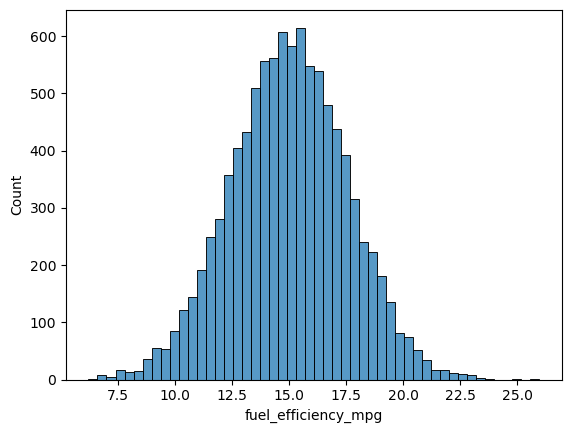

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df.fuel_efficiency_mpg, bins=50)
plt.show()

In [33]:
n = len(df)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)
df = df.iloc[idx]

In [34]:
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [35]:
n_val, n_train, n_test

(1940, 5824, 1940)

In [36]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train : n_train + n_val]
df_test = df.iloc[n_train + n_val : ]

In [37]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [38]:
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True) 
df_test.reset_index(drop=True, inplace=True)

In [39]:
df_train
df_val
df_test

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,210,NaN,2187.416710,2019,17.926270
1,200,185.0,3668.245505,2016,11.911604
2,190,158.0,3268.276283,2001,13.848763
3,100,159.0,3154.174688,2002,14.817145
4,230,136.0,3124.071342,2020,14.111973
...,...,...,...,...,...
1935,150,142.0,3335.837691,2009,13.457854
1936,170,192.0,2180.152805,2002,20.442089
1937,230,134.0,2940.073942,2007,15.107077
1938,190,107.0,3070.350393,2002,14.231137


In [40]:
print(df_train.columns)
print(df_val.columns)
print(df_test.columns)

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='object')
Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='object')
Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='object')


In [41]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# Filling missing value with zero

In [70]:
def prepare_x(df):
    df = df.copy()
    df =df.fillna(0)
    X = df.values
    return X

In [71]:
X_train = prepare_x(df_train)
X_val = prepare_x(df_val)
X_test = prepare_x(df_test)

In [72]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(5824, 4)
(1940, 4)
(1940, 4)


In [73]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [74]:
w0, w = train_linear_regression(X_train, y_train)

In [75]:
w0, w

(np.float64(27.928074749517876),
 array([ 0.00018271,  0.00339941, -0.00499276,  0.00076253]))

In [79]:
y_pred = w0 + X_val.dot(w)

In [80]:
def rmse(y, y_pred):
    se = ( y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [81]:
score  = rmse(y_val, y_pred)

In [82]:
print(round(score, 2))

0.52


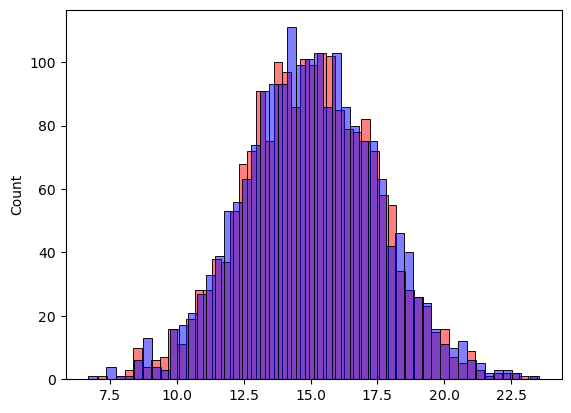

In [83]:
sns.histplot(y_pred, color='red', alpha = 0.5, bins=50)
sns.histplot(y_val, color = 'blue', alpha = 0.5, bins=50)
plt.show()

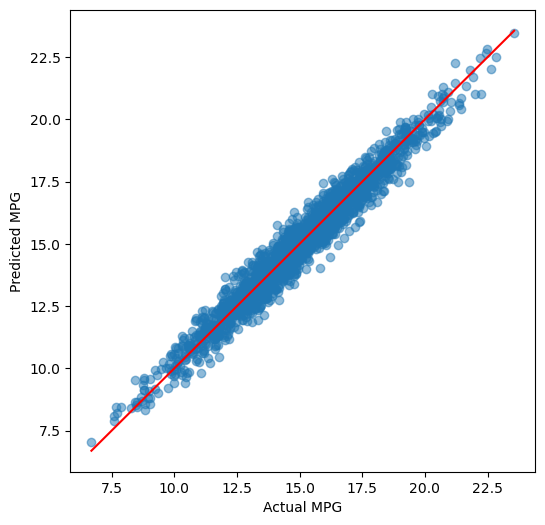

In [84]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red'
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.show()

# filling misssing value with mean of training

In [85]:
mean_hp = df_train.horsepower.mean()

In [86]:
print(mean_hp)

149.31600370027752


In [87]:
def prepare_x(df):
    df = df.copy()
    df = df.fillna(mean_hp)
    X = df.values
    return X

In [88]:
X_train = prepare_x(df_train)
X_val = prepare_x(df_val)

In [89]:
w0, w = train_linear_regression(X_train, y_train)

In [90]:
y_pred = w0 + X_val.dot(w)

In [91]:
score = rmse(y_val, y_pred)

In [92]:
print(round(score, 2))

0.46


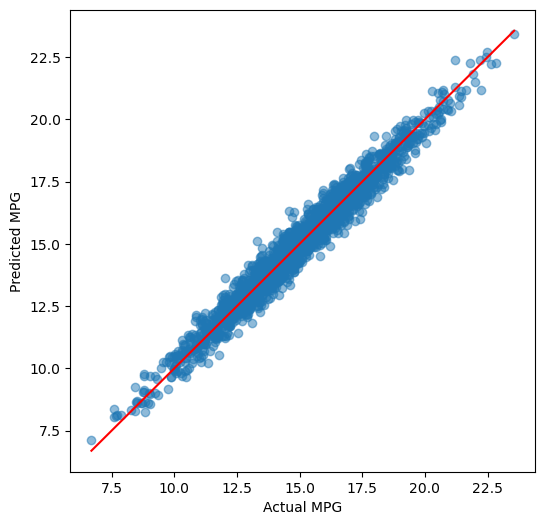

In [93]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red'
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.show()